# Análisis del Dataset H-AIRosettaMP

Este notebook evalúa los datos del CSV para analizar:
- **Códigos por lenguaje**: Cuántos códigos hay de cada lenguaje
- **Origen**: Códigos generados por humanos vs IA
- **Duplicados**: Cuántos códigos duplicados hay por lenguaje y target (humanos/IA)

## 1. Importar Librerías

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurar estilos para mejor visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Cargar y Explorar los Datos

Cargar CSV y mostrar las primeras filas junto con información sobre la estructura del dataset.

In [29]:
# Cargar el CSV
csv_path = '../../data/H-AIRosettaMP.csv'
df = pd.read_csv(csv_path)

# Mostrar información básica del dataset
print("Forma del dataset:", df.shape)
print("\nColumnas del dataset:")
print(df.columns.tolist())
print("\nValores faltantes por columna:")
print(df.isnull().sum())
print("\nInfo general del dataset:")
df.info()

Forma del dataset: (121247, 7)

Columnas del dataset:
['task_url', 'task_name', 'task_description', 'language_name', 'code', 'target', 'set']

Valores faltantes por columna:
task_url             0
task_name            0
task_description    52
language_name        0
code                42
target               0
set                  0
dtype: int64

Info general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121247 entries, 0 to 121246
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   task_url          121247 non-null  object
 1   task_name         121247 non-null  object
 2   task_description  121195 non-null  object
 3   language_name     121247 non-null  object
 4   code              121205 non-null  object
 5   target            121247 non-null  object
 6   set               121247 non-null  object
dtypes: object(7)
memory usage: 6.5+ MB


In [30]:
df["target"].unique()

array(['Ai_generated', 'Human_written'], dtype=object)

## 3. Contar Códigos por Lenguaje de Programación

Análisis de cuántos códigos existen para cada lenguaje de programación.

Columnas posibles de lenguaje: ['language_name']

=== Códigos por Lenguaje (language_name) ===
language_name
Go            13763
Python        13737
Ruby          13335
Java          12351
Kotlin        12256
cpp           12029
C             11715
C#            11331
Rust          10665
JavaScript    10065
Name: count, dtype: int64

Total de lenguajes únicos: 10
Total de códigos: 121247


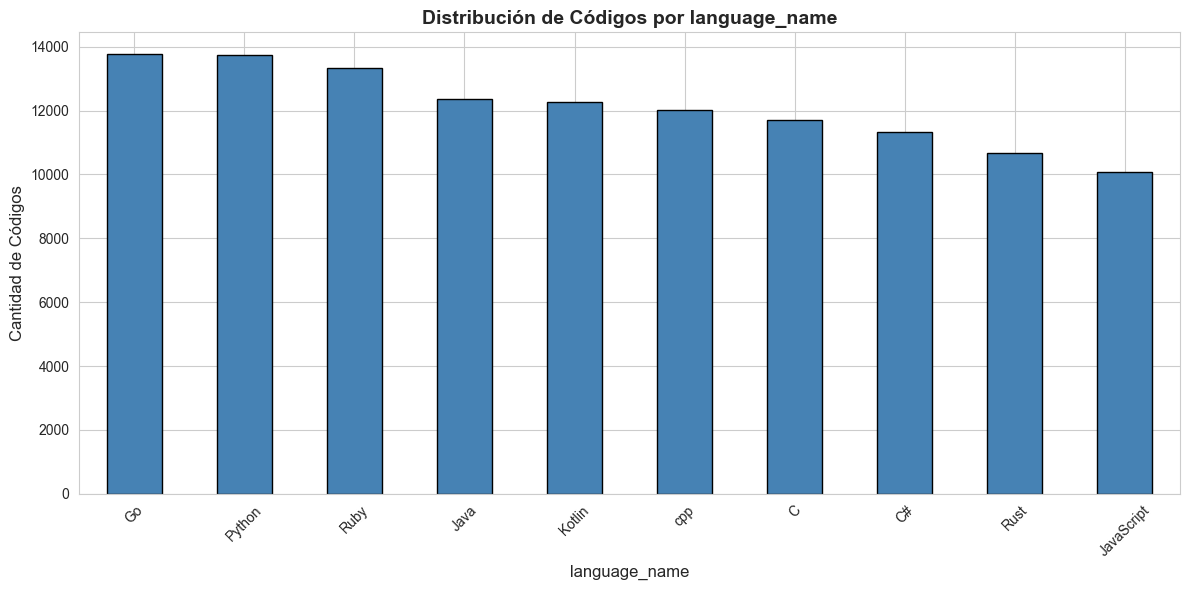

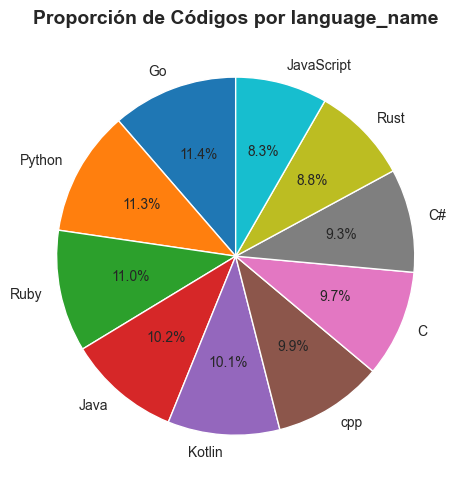

In [31]:
# Buscar columnas relacionadas con lenguaje
language_cols = [col for col in df.columns if 'language' in col.lower() or 'lang' in col.lower()]
print(f"Columnas posibles de lenguaje: {language_cols}")

if language_cols:
    lang_col = language_cols[0]
    print(f"\n=== Códigos por Lenguaje ({lang_col}) ===")
    language_counts = df[lang_col].value_counts()
    print(language_counts)
    print(f"\nTotal de lenguajes únicos: {len(language_counts)}")
    print(f"Total de códigos: {language_counts.sum()}")
else:
    print("\nNo se encontró columna de lenguaje. Mostrando todas las columnas:")
    print(df.columns.tolist())

# Visualización de la distribución de lenguajes
# 1: Gráfico de Barras
lang_col = language_cols[0]
language_counts = df[lang_col].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
language_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title(f'Distribución de Códigos por {lang_col}', fontsize=14, fontweight='bold')
ax.set_xlabel(lang_col, fontsize=12)
ax.set_ylabel('Cantidad de Códigos', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 2: Gráfico de Pastel
fig, ax = plt.subplots(figsize=(8, 5))
language_counts.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
ax.set_title(f'Proporción de Códigos por {lang_col}', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 4. Comparar Códigos Generados por Humanos vs IA por Lenguaje

Análisis de la distribución entre códigos generados por humanos e inteligencia artificial por lenguaje de programación.

=== Códigos por Lenguaje y Origen (Humano vs IA) ===
target         Ai_generated  Human_written     All
language_name                                     
C                      5858           5857   11715
C#                     5666           5665   11331
Go                     6877           6886   13763
Java                   6176           6175   12351
JavaScript             5033           5032   10065
Kotlin                 6128           6128   12256
Python                 6869           6868   13737
Ruby                   6668           6667   13335
Rust                   5333           5332   10665
cpp                    6015           6014   12029
All                   60623          60624  121247


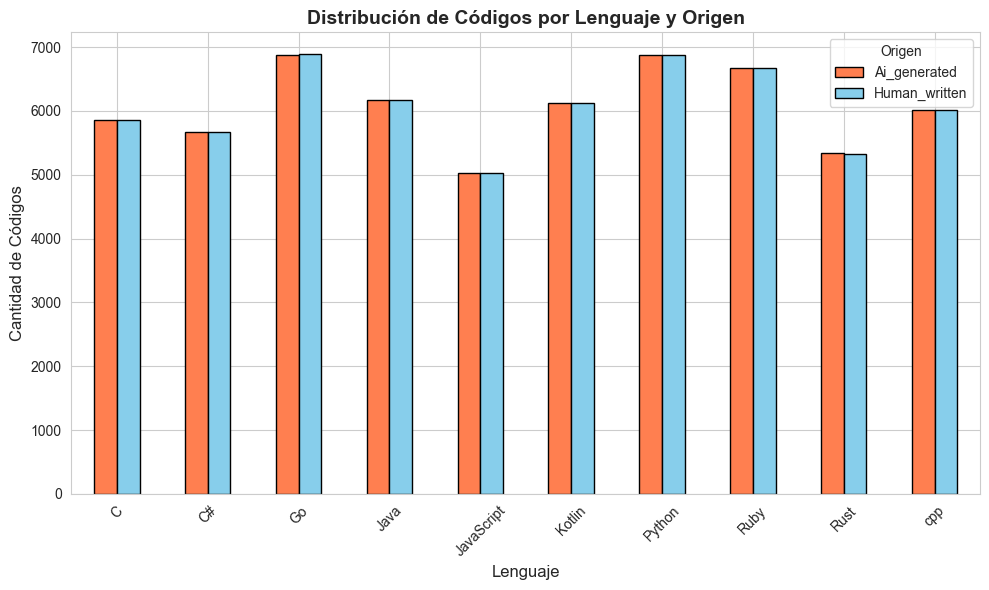

In [32]:
# Crear tabla cruzada de language_name vs target
crossstab_lang_target = pd.crosstab(df['language_name'], df['target'], margins=True)
print("=== Códigos por Lenguaje y Origen (Humano vs IA) ===")
print(crossstab_lang_target)

# Visualizar en gráfico
fig, ax = plt.subplots(figsize=(10, 6))
crossstab_lang_target.iloc[:-1, :-1].plot(kind='bar', ax=ax, color=['coral', 'skyblue'], edgecolor='black')
ax.set_title('Distribución de Códigos por Lenguaje y Origen', fontsize=14, fontweight='bold')
ax.set_xlabel('Lenguaje', fontsize=12)
ax.set_ylabel('Cantidad de Códigos', fontsize=12)
ax.legend(title='Origen', fontsize=10)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Evaluar Códigos Duplicados

Revisar por lenguaje cuántos códigos duplicados por origen (humano o AI) hay en la base de datos.

In [33]:
# Calcular duplicados en "code" por lenguaje y origen (Ai_generated vs Human_written)
duplicates_per_lang = df.groupby(['language_name', 'target'])['code'].apply(lambda x: x.duplicated().sum()).unstack(fill_value=0)
print("Número de códigos duplicados por lenguaje y origen:")

# Agregar totales por lenguaje
duplicates_per_lang['Total'] = duplicates_per_lang.sum(axis=1)
print("\nCon totales por lenguaje:")
print(duplicates_per_lang)

Número de códigos duplicados por lenguaje y origen:

Con totales por lenguaje:
target         Ai_generated  Human_written  Total
language_name                                    
C                        20           4882   4902
C#                       24           4853   4877
Go                       58           5777   5835
Java                     32           5205   5237
JavaScript               32           4340   4372
Kotlin                   55           5137   5192
Python                   67           5783   5850
Ruby                     52           5691   5743
Rust                     58           4536   4594
cpp                      16           5075   5091


In [34]:
# Calcular el número total de códigos por lenguaje y origen (incluyendo duplicados)
total_counts = pd.crosstab(df['language_name'], df['target'])

# Restar los duplicados
unique_counts = total_counts - duplicates_per_lang

# Calcular el número de códigos únicos por lenguaje y origen (eliminando duplicados)
unique_counts['Total'] = unique_counts.sum(axis=1)

# Imprimir los resultados
print("Número de códigos únicos por lenguaje y origen (eliminando duplicados):")
print(unique_counts)

Número de códigos únicos por lenguaje y origen (eliminando duplicados):
target         Ai_generated  Human_written   Total
language_name                                     
C                      5838            975  6813.0
C#                     5642            812  6454.0
Go                     6819           1109  7928.0
Java                   6144            970  7114.0
JavaScript             5001            692  5693.0
Kotlin                 6073            991  7064.0
Python                 6802           1085  7887.0
Ruby                   6616            976  7592.0
Rust                   5275            796  6071.0
cpp                    5999            939  6938.0


## 6. Seleccionar un Lenguaje para Eliminar Duplicados

Crear un dataframe de un sólo lenguaje sin duplicados para analizar la composición de los datos.

In [35]:
cpp_unique_df = df[df['language_name'] == 'cpp'].dropna(subset=['code']).drop_duplicates(subset=['code']).reset_index(drop=True)
print(f"Forma del nuevo dataset: {cpp_unique_df.shape}")

Forma del nuevo dataset: (6930, 7)


=== Códigos por Origen (Humano vs IA) ===
target
Ai_generated     5992
Human_written     938
Name: count, dtype: int64

Porcentajes:
target
Ai_generated     86.46
Human_written    13.54
Name: proportion, dtype: float64


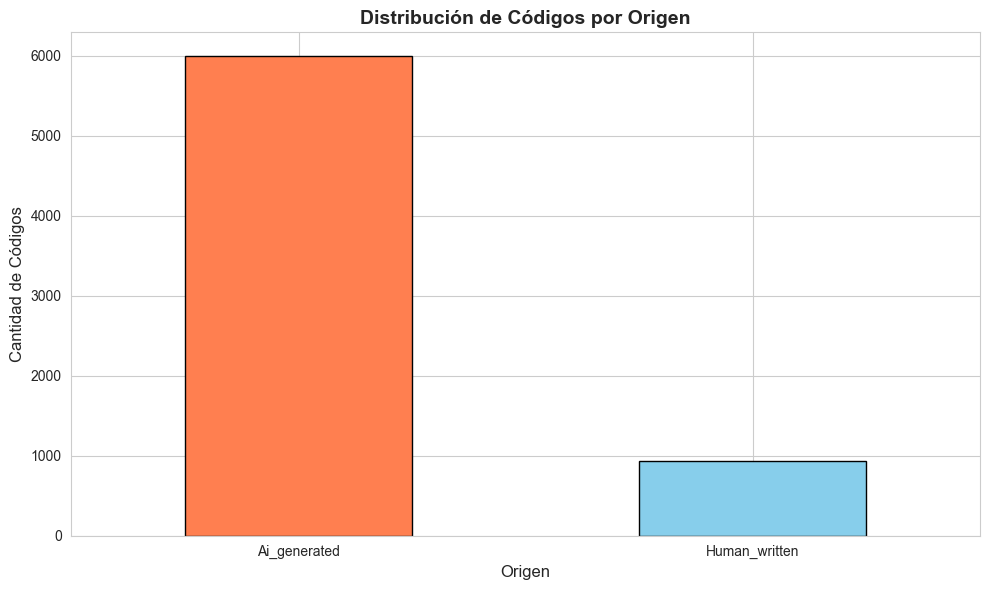

In [36]:
# Contar códigos por origen en el dataset único de C++
target_counts_cpp = cpp_unique_df['target'].value_counts()
print("=== Códigos por Origen (Humano vs IA) ===")
print(target_counts_cpp)

# Porcentajes
target_pct_cpp = cpp_unique_df['target'].value_counts(normalize=True) * 100
print("\nPorcentajes:")
print(target_pct_cpp.round(2))

# Visualizar en gráfico
fig, ax = plt.subplots(figsize=(10, 6))
target_counts_cpp.plot(kind='bar', ax=ax, color=['coral', 'skyblue'], edgecolor='black')
ax.set_title('Distribución de Códigos por Origen', fontsize=14, fontweight='bold')
ax.set_xlabel('Origen', fontsize=12)
ax.set_ylabel('Cantidad de Códigos', fontsize=12)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()